# Heart Disease Prediction 

This notebook documents the process of building Heart Disease Prediction model using the **Heart Failure Prediction Dataset** (918 rows).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os 
sns.set_style('whitegrid')

# Machine Learning Essential Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import shap , warnings

warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('data/heart.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

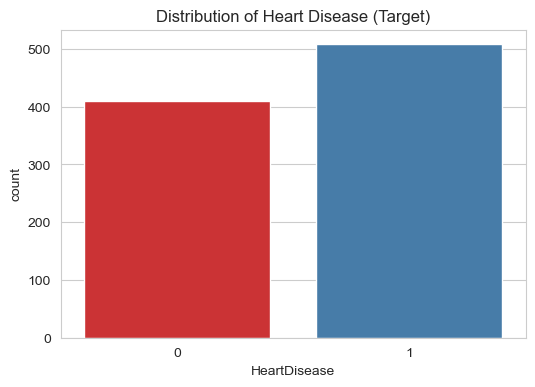

In [5]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HeartDisease',palette = 'Set1')
plt.title('Distribution of Heart Disease (Target)')
plt.show()

In [6]:
print("---- Data Info ----")
df.info()

---- Data Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
print('--- Summary Stats ---')
df.describe()

--- Summary Stats ---


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Numerical Features Analysis
Analyzed the distribution of numerical features and their relationship with the target variable (HeartDisease).

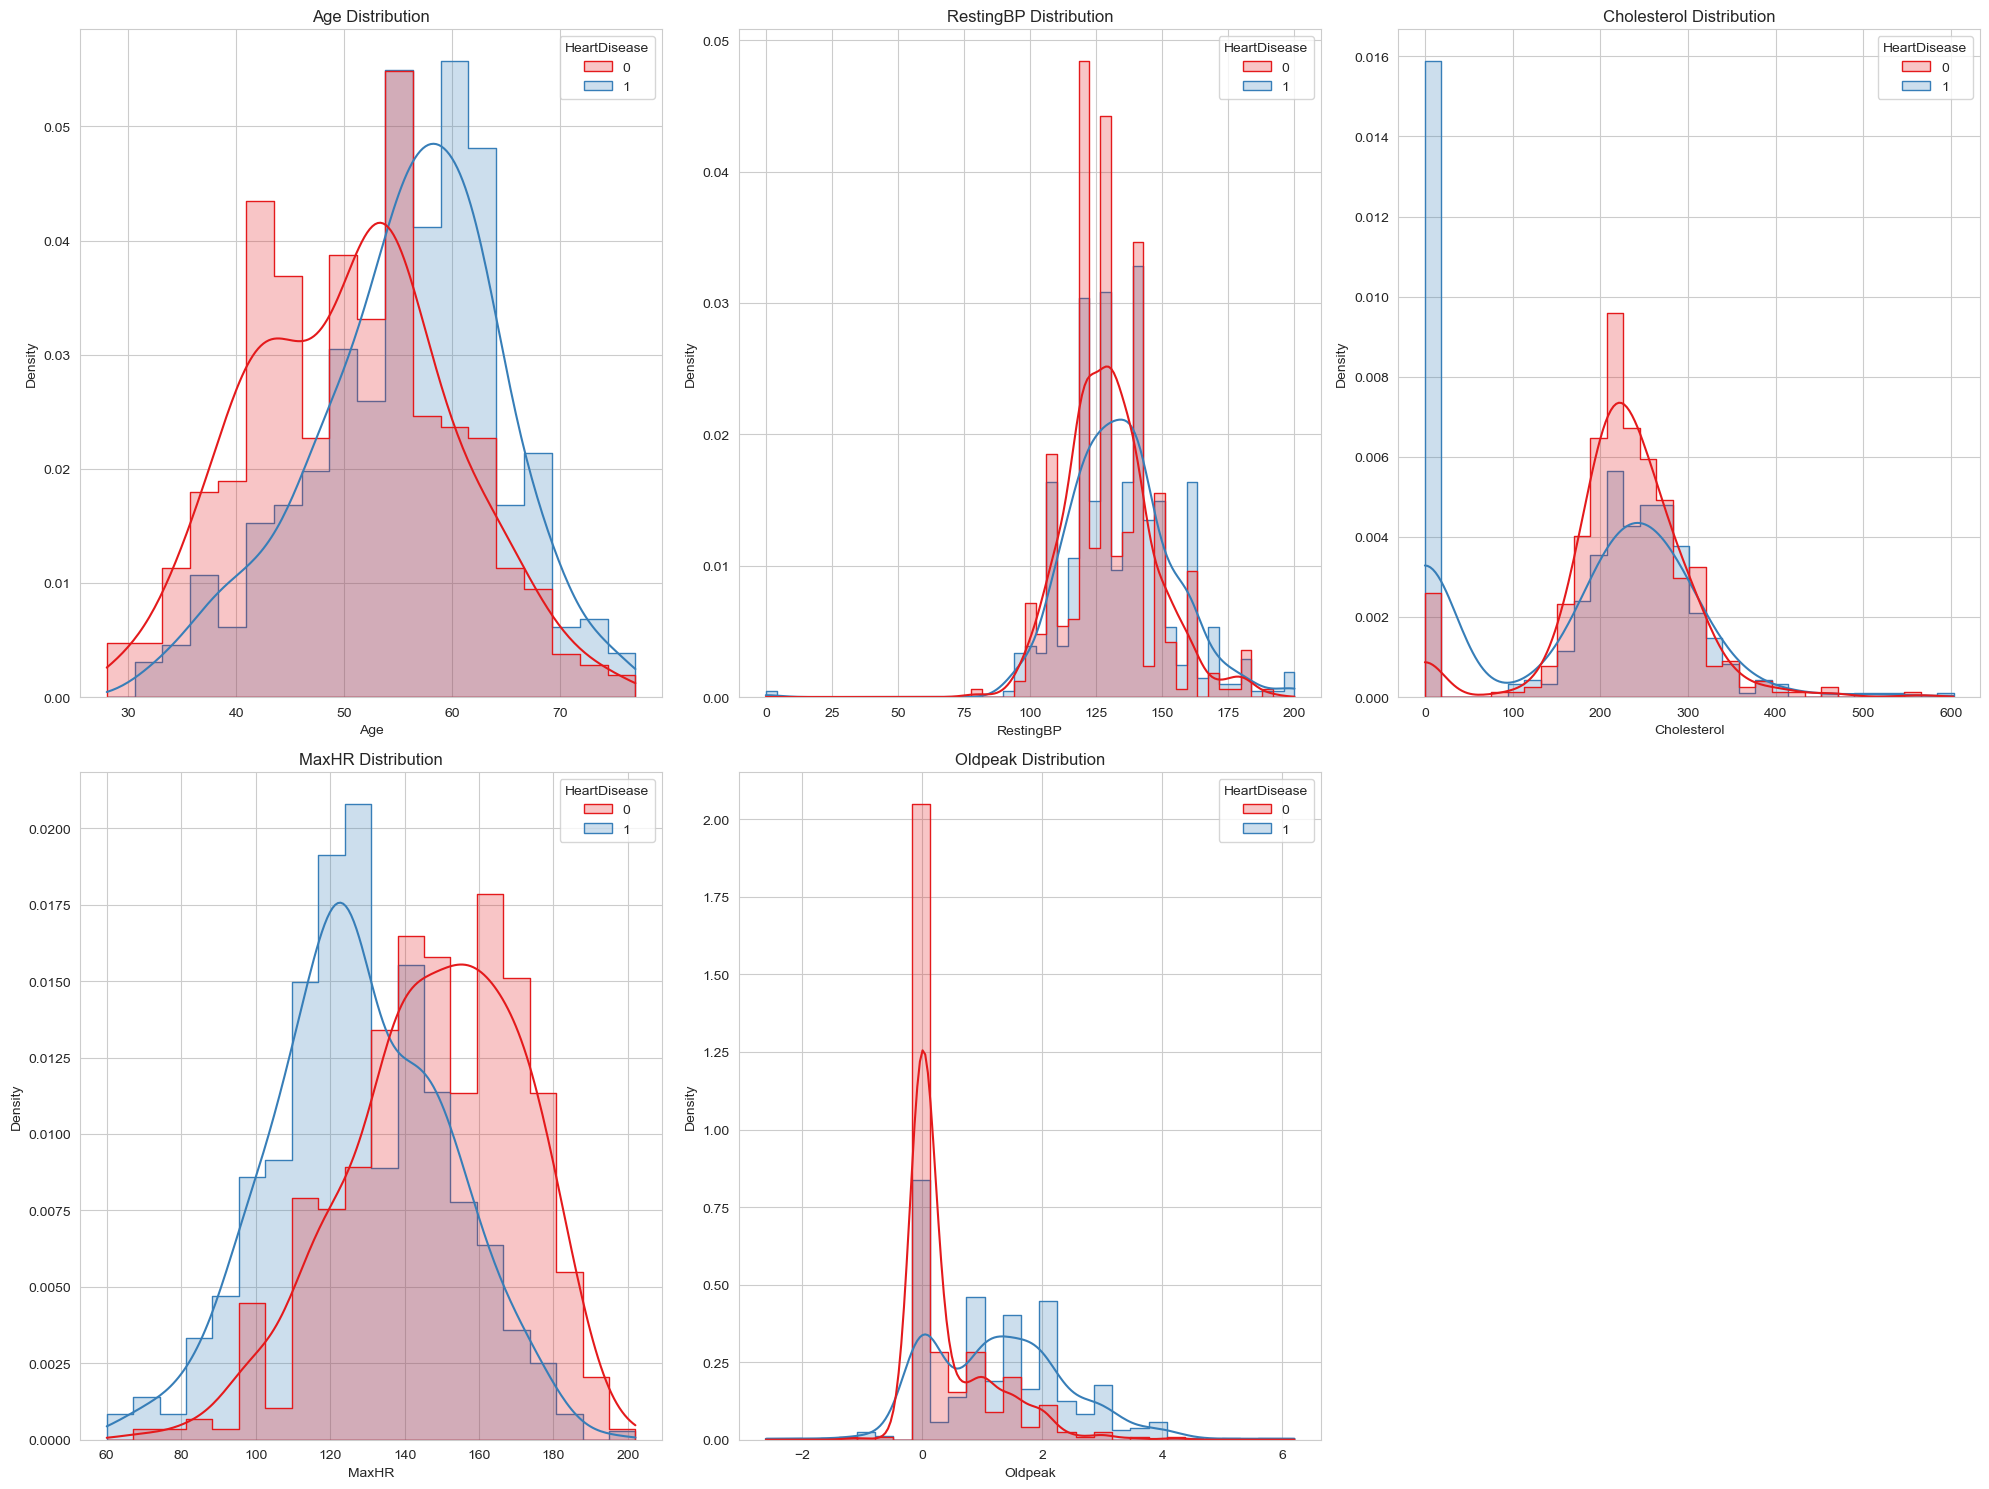

In [8]:
numeric_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

plt.figure(figsize=(20,15))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(
        data=df,
        x=col,
        hue='HeartDisease',
        kde=True,
        stat='density',
        common_norm=False,
        element='step',
        palette='Set1')

    plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

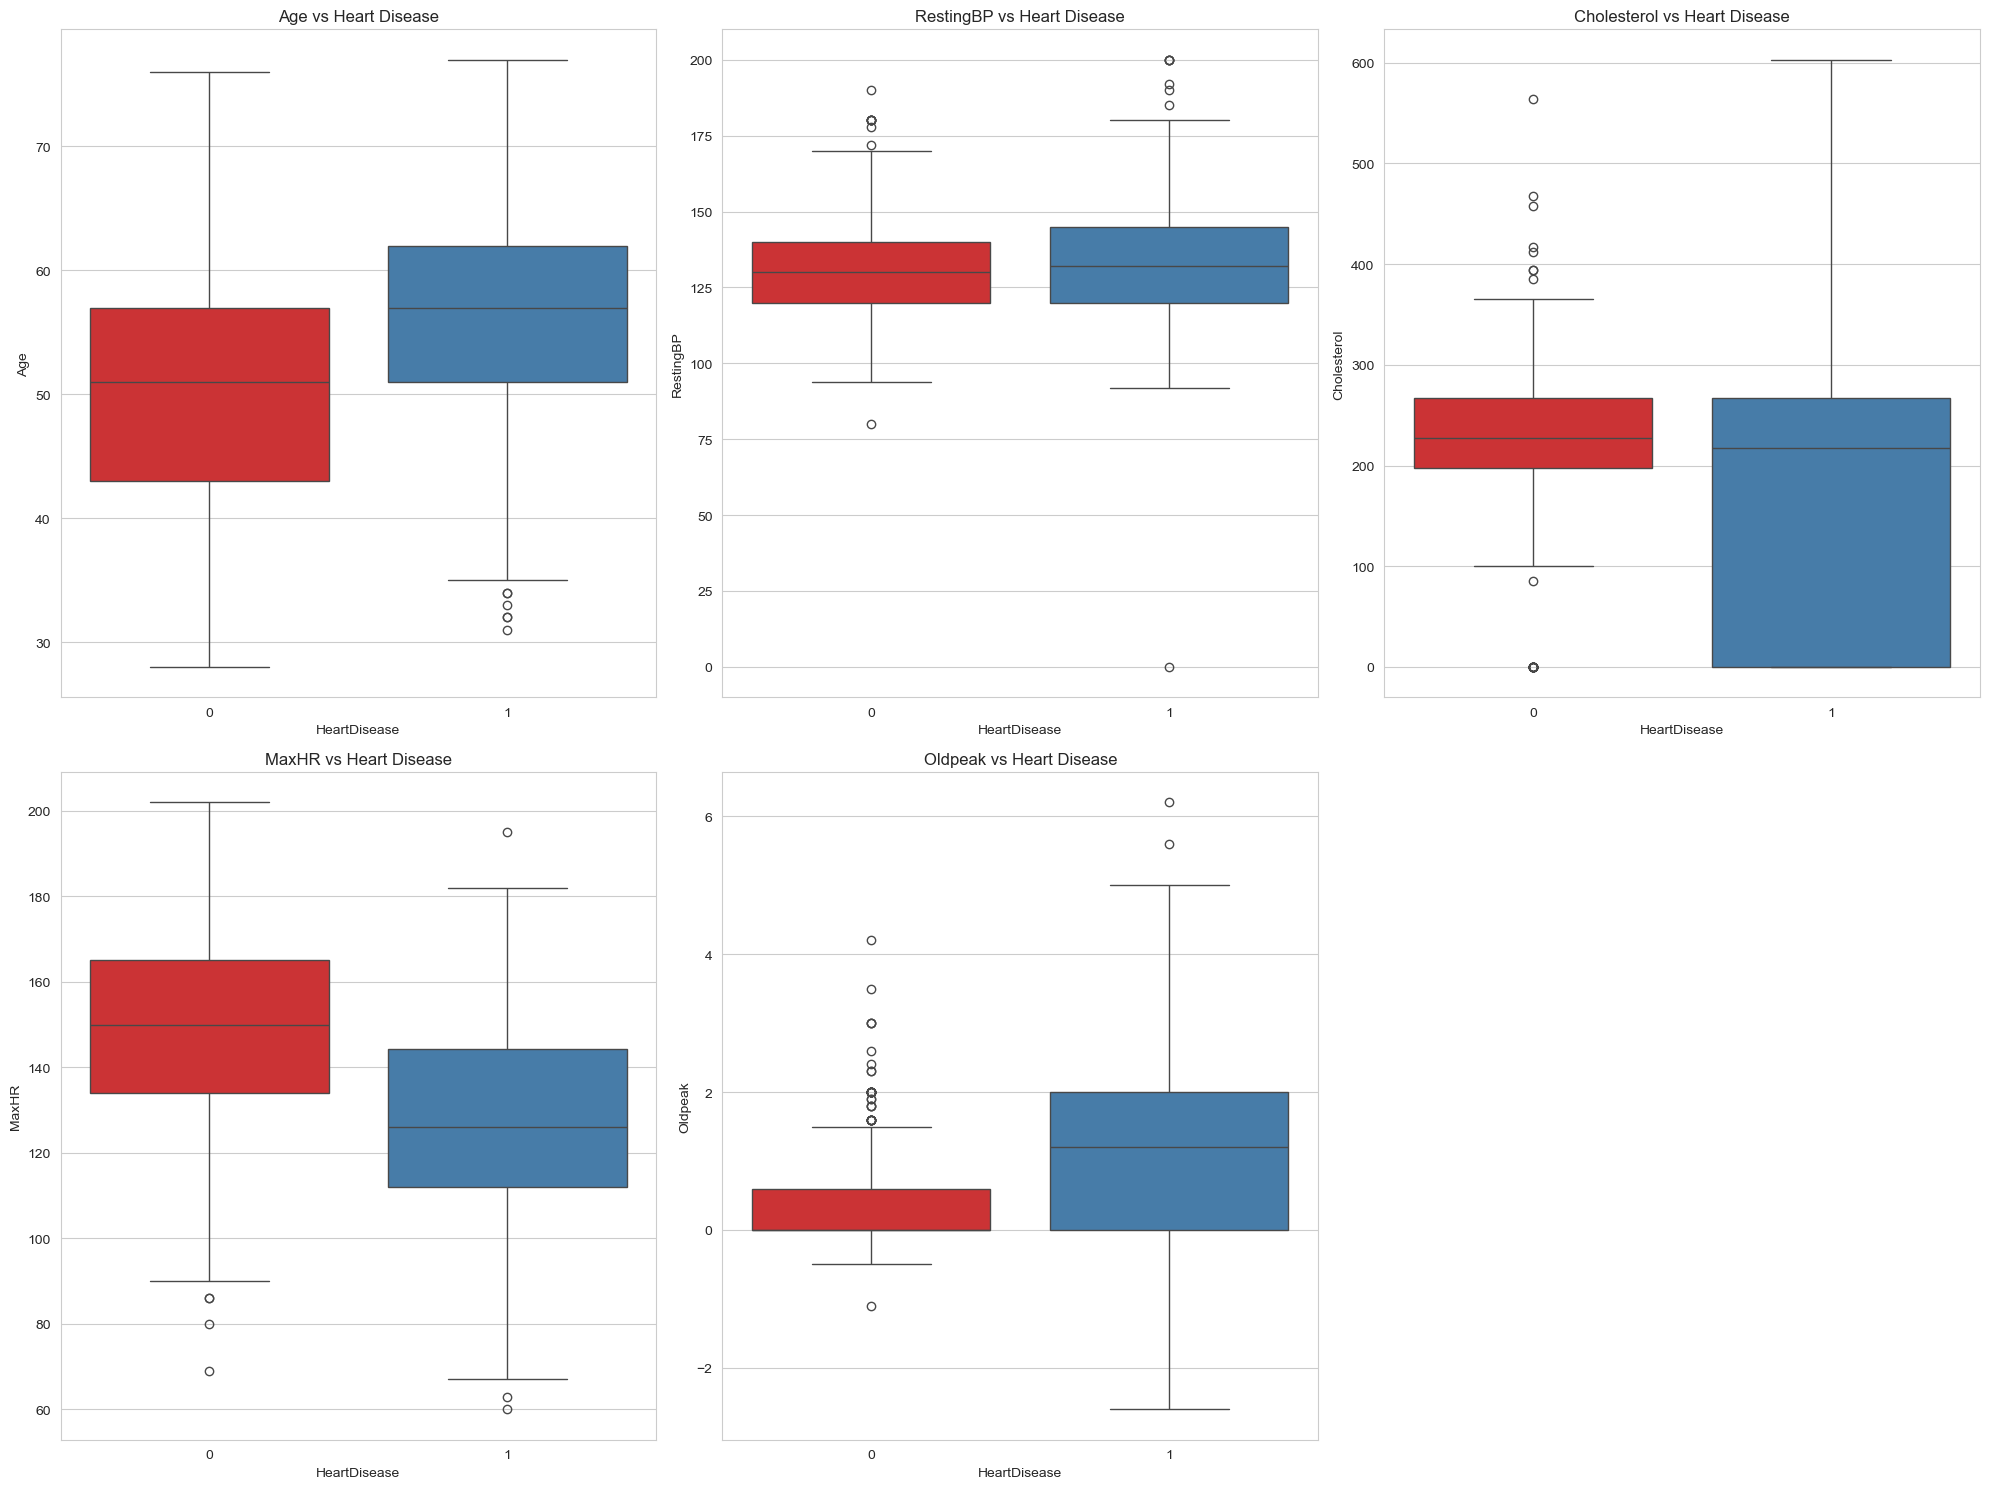

In [14]:
plt.figure(figsize=(20,15))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=df,
                x='HeartDisease',
                y=col,
                palette='Set1')
    plt.title(f'{col} vs Heart Disease')
plt.tight_layout()
plt.show()

### Categorical Features Analysis

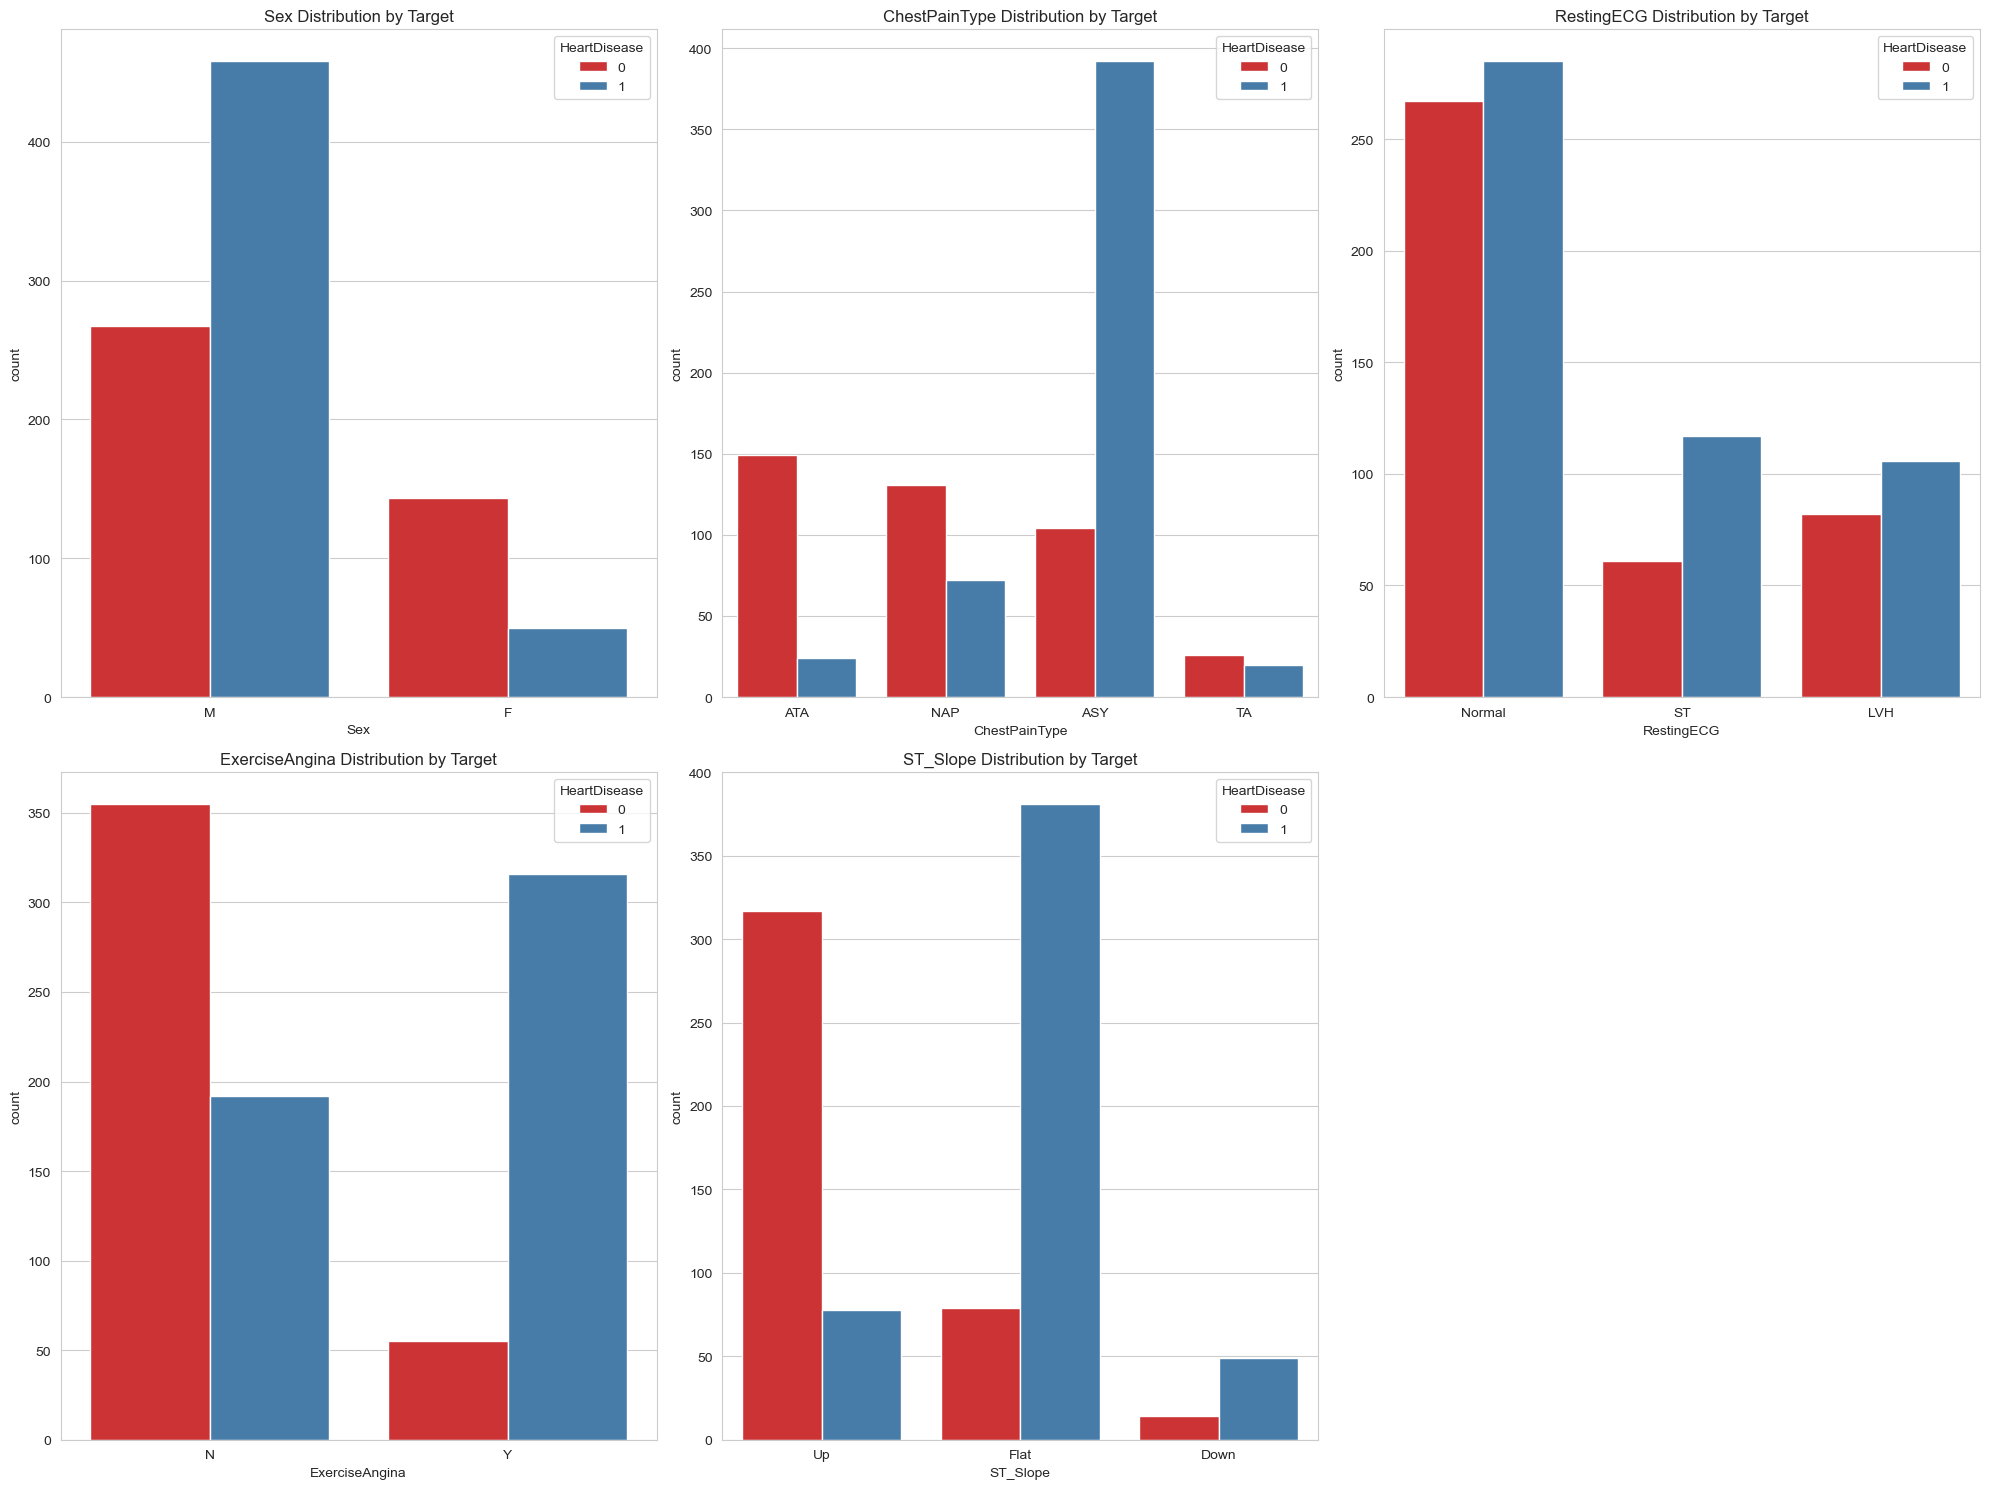

In [15]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
plt.figure(figsize=(20,15))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(data=df,
                  x=col,
                  hue='HeartDisease',
                  palette='Set1')
    plt.title(f'{col} Distribution by Target')
plt.tight_layout()
plt.show()

### Correlation Matrix

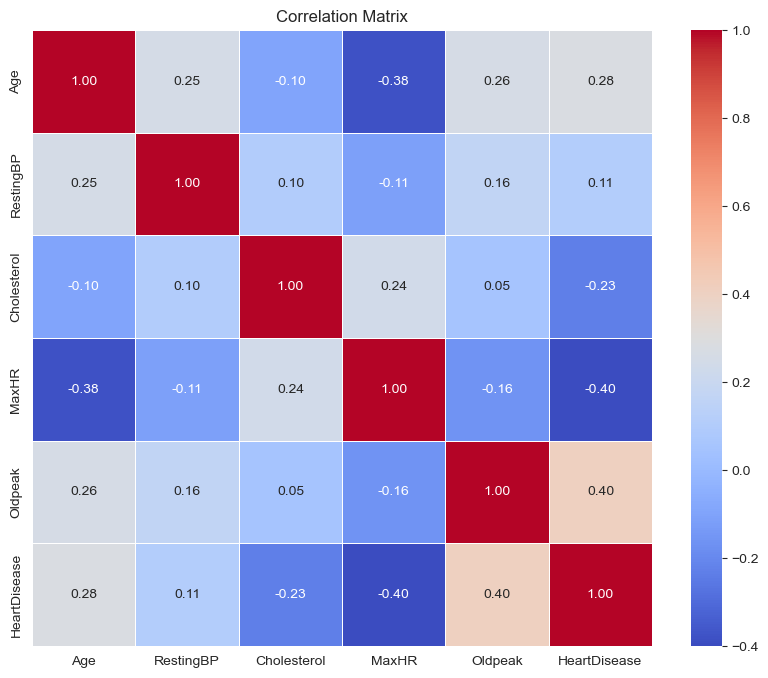

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols + ['HeartDisease']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.show()

### Preprocessing

In [ ]:
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scale numbers
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features) # Converting text to numbers
    ])

### Split Data

In [19]:
# Splitting the data into Training (80%) and Testing (20%)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 734
Testing samples: 184


### Model Training

In [24]:
# --- Random Forest ---

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc:.2%}")


Random Forest Accuracy: 88.04%
